In [1]:
import json
import pandas as pd
import re
import nltk
import time
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from lime.lime_text import LimeTextExplainer

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gaura\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\gaura\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [2]:
#Load and Preprocess Data
reviews = []
with open('yelp_academic_dataset_review.json', 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i >= 26000:
            break
        review = json.loads(line)
        reviews.append({
            'review_id': review['review_id'],
            'user_id': review['user_id'],
            'business_id': review['business_id'],
            'stars': review['stars'],
            'date': review['date'],
            'text': review['text'],
            'useful': review['useful'],
            'funny': review['funny'],
            'cool': review['cool']
        })

In [3]:
df = pd.DataFrame(reviews)
df['label'] = df['stars'].apply(lambda x: 'Positive' if x >=4 else 'Neutral' if x ==3 else 'Negative')
df.to_csv('yelp_reviews.csv', index=False)

In [4]:
df.head()

,review_id,user_id,business_id,stars,date,text,useful,funny,cool,label
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,2018-07-07 22:09:11,"If you decide to eat here, just be aware it is...",0,0,0,Neutral
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5.0,2012-01-03 15:28:18,I've taken a lot of spin classes over the year...,1,0,1,Positive
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3.0,2014-02-05 20:30:30,Family diner. Had the buffet. Eclectic assortm...,0,0,0,Neutral
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5.0,2015-01-04 00:01:03,"Wow! Yummy, different, delicious. Our favo...",1,0,1,Positive
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4.0,2017-01-14 20:54:15,Cute interior and owner (?) gave us tour of up...,1,0,1,Positive


In [5]:
# Load the CSV
df = pd.read_csv('yelp_reviews.csv')

In [6]:
# Check the first 5 rows
df.head()

,review_id,user_id,business_id,stars,date,text,useful,funny,cool,label
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,2018-07-07 22:09:11,"If you decide to eat here, just be aware it is...",0,0,0,Neutral
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5.0,2012-01-03 15:28:18,I've taken a lot of spin classes over the year...,1,0,1,Positive
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3.0,2014-02-05 20:30:30,Family diner. Had the buffet. Eclectic assortm...,0,0,0,Neutral
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5.0,2015-01-04 00:01:03,"Wow! Yummy, different, delicious. Our favo...",1,0,1,Positive
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4.0,2017-01-14 20:54:15,Cute interior and owner (?) gave us tour of up...,1,0,1,Positive


In [7]:
# Check class distribution
print(df['label'].value_counts())

label
Positive    18199
Negative     4847
Neutral      2954
Name: count, dtype: int64


In [8]:
df.shape

(26000, 10)

In [9]:
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

In [10]:
# Text preprocessing
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return ' '.join(words)

df['clean_text'] = df['text'].apply(preprocess_text)

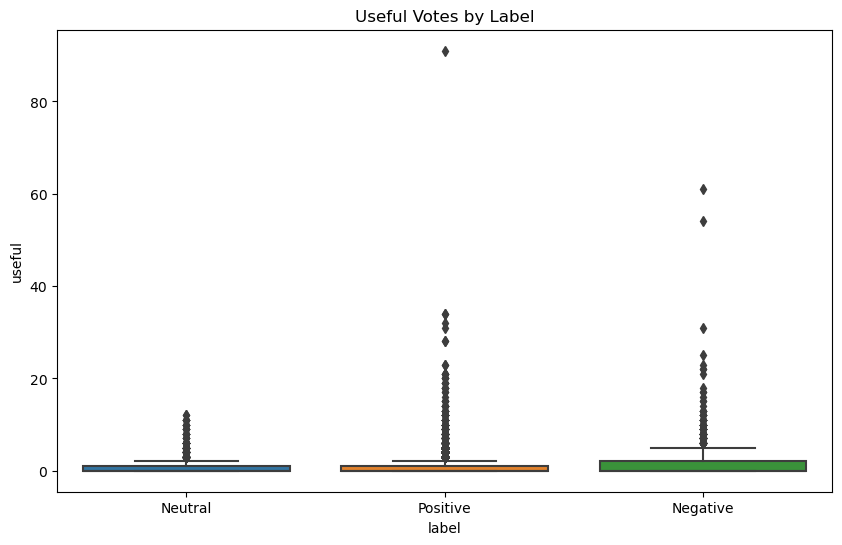

In [11]:
# Plot distribution of votes
plt.figure(figsize=(10, 6))
sns.boxplot(x='label', y='useful', data=df)
plt.title('Useful Votes by Label')
plt.show()

<Figure size 1000x600 with 0 Axes>

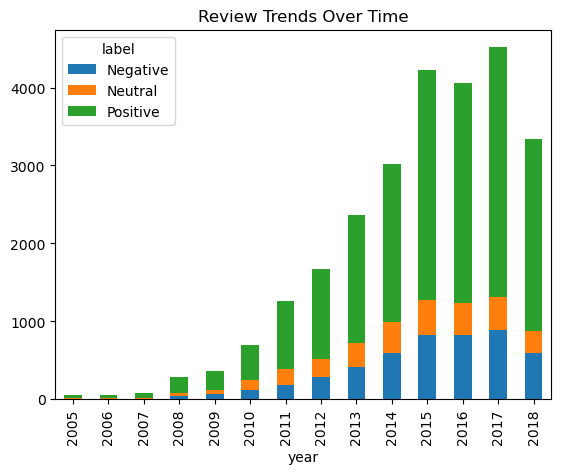

In [12]:
# Analyze temporal trends
plt.figure(figsize=(10, 6))
df.groupby(['year', 'label']).size().unstack().plot(kind='bar', stacked=True)
plt.title('Review Trends Over Time')
plt.show()

In [13]:
# Train-Test Split
X = df[['clean_text', 'useful', 'funny', 'cool', 'month']]
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [14]:
# Build Pipeline with Naive Bayes
text_features = 'clean_text'
numeric_features = ['useful', 'funny', 'cool']
categorical_features = ['month']

preprocessor = ColumnTransformer(
    transformers=[
        ('text', CountVectorizer(ngram_range=(1,1)), text_features),
        ('num', MinMaxScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', MultinomialNB(alpha=1.0))
])

In [15]:
# Train model
start_time = time.time()
model.fit(X_train, y_train)
train_time = time.time() - start_time
print(f"Training Time: {train_time:.2f} seconds")

Training Time: 0.80 seconds



Training Set Classification Report:
              precision    recall  f1-score   support

    Negative       0.78      0.80      0.79      3878
     Neutral       0.74      0.44      0.55      2363
    Positive       0.90      0.96      0.93     14559

    accuracy                           0.87     20800
   macro avg       0.81      0.73      0.76     20800
weighted avg       0.86      0.87      0.86     20800



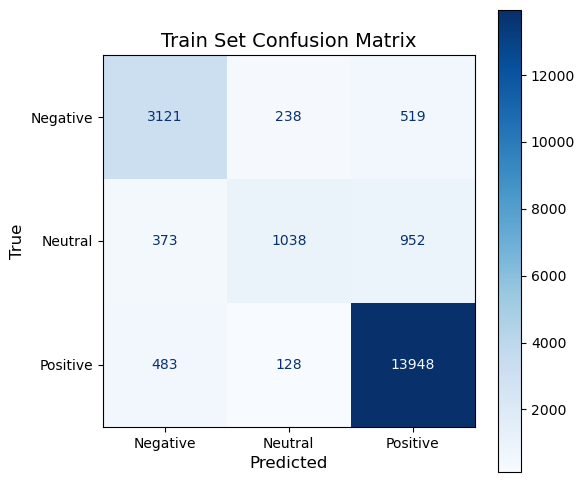

In [16]:
# Training set predictions
y_train_pred = model.predict(X_train)

# Training classification report
print("\nTraining Set Classification Report:")
print(classification_report(y_train, y_train_pred))

# Training confusion matrix
cm_train = confusion_matrix(y_train, y_train_pred)

# Create ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_train,
    display_labels=model.classes_  # Class names (Negative/Neutral/Positive)
)

# Plot with formatting
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, cmap='Blues', values_format='d')  # 'd' = integer formatting
plt.title('Train Set Confusion Matrix', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.xtlabels = ax.get_xticklabels()
plt.ytlabels = ax.get_yticklabels()
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.show()


Test Set Classification Report:
              precision    recall  f1-score   support

    Negative       0.72      0.72      0.72       969
     Neutral       0.41      0.19      0.26       591
    Positive       0.86      0.94      0.90      3640

    accuracy                           0.81      5200
   macro avg       0.66      0.61      0.62      5200
weighted avg       0.78      0.81      0.79      5200



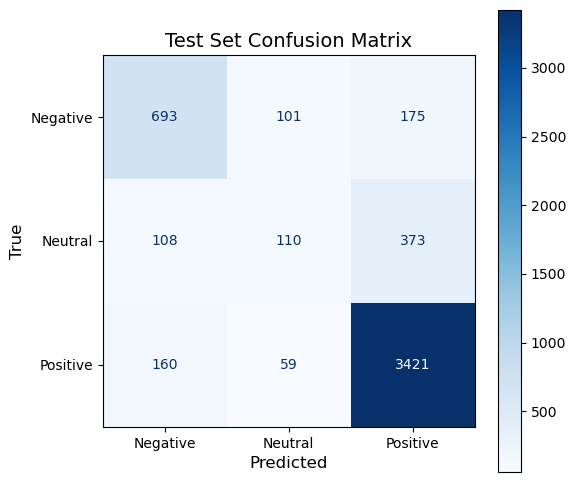

In [17]:
# Test set predictions
y_test_pred = model.predict(X_test)

# Test classification report
print("\nTest Set Classification Report:")
print(classification_report(y_test, y_test_pred))

# Test confusion matrix
cm_test = confusion_matrix(y_test, y_test_pred)

# Create ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=model.classes_  # Class names (Negative/Neutral/Positive)
)

# Plot with formatting
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, cmap='Blues', values_format='d')  # 'd' = integer formatting
plt.title('Test Set Confusion Matrix', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.xtlabels = ax.get_xticklabels()
plt.ytlabels = ax.get_yticklabels()
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.show()

In [18]:
# Cross-Validation
cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
print(f"\nCross-Validation Accuracy: {cv_scores.mean():.2f} (±{cv_scores.std():.2f})")


Cross-Validation Accuracy: 0.81 (±0.00)


In [19]:
# STEP 9: Plot AUC Curve 
# Encode labels
le = LabelEncoder()
y_test_num = le.fit_transform(y_test)
y_probs = model.predict_proba(X_test)

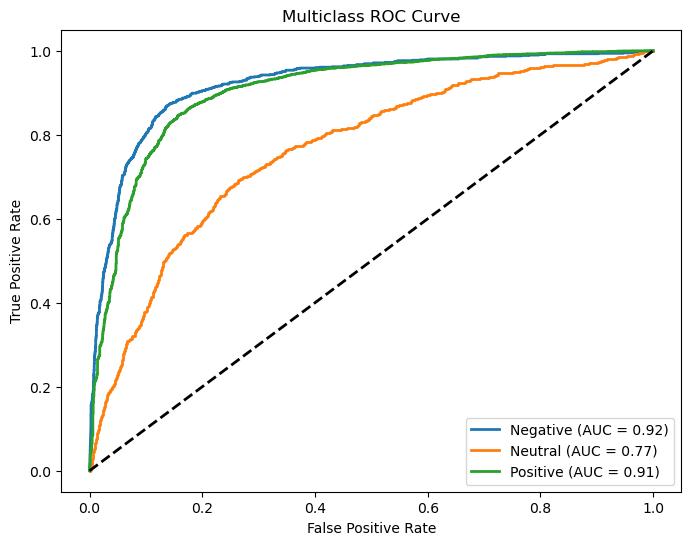

In [20]:
# Compute ROC curves
n_classes = len(le.classes_)
fpr, tpr, roc_auc = {}, {}, {}

plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_num, y_probs[:, i], pos_label=i)
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], lw=2,
             label=f'{le.classes_[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve')
plt.legend(loc="lower right")
plt.show()

In [21]:
from lime.lime_text import LimeTextExplainer

# Get class names from the model
classifier = model.named_steps['classifier']
classes = classifier.classes_  

# Wrap the pipeline for LIME compatibility
def predict_proba_wrapper(texts):
    df_dummy = pd.DataFrame({
        'clean_text': texts,
        'useful': [df['useful'].mean()] * len(texts),
        'funny': [df['funny'].mean()] * len(texts),
        'cool': [df['cool'].mean()] * len(texts),
        'month': [df['month'].mode()[0]] * len(texts)
    })
    return model.predict_proba(df_dummy)

In [22]:
# Explain a test instance (e.g., index 10)
explainer = LimeTextExplainer(class_names=classes)
exp = explainer.explain_instance(
    X_test.iloc[1002]['clean_text'], 
    predict_proba_wrapper, 
    num_features=10
)
exp.show_in_notebook(text=True)

# naive bais model using count vectors for Unigram result table

In [51]:
# Provide the file path of the Excel file
file_path = 'result_table-swetha.xlsx'
pd.set_option('display.max_colwidth', None)

# Load the Excel file into a DataFrame
df_result = pd.read_excel(file_path)

# Display the first few rows of the DataFrame
df_result

,Task,Status,Results,Individual Responsible
0,Config of the model trained,completed,"CountVectorizer(ngram_range=(1,1)) + MultinomialNB(alpha=1.0) with MinMaxScaler (numeric) and OneHotEncoder (categorical).",Swetha
1,Train Time = ?,completed,0.80 seconds,Swetha
2,Training Data Check,completed,"Sample Size: 20,800",Swetha
3,Confusion Matrix Built?,completed,yes,Swetha
4,F1 Score for Positive = ?,completed,Training: 0.93,Swetha
5,F1 Score for Negative = ?,completed,Training: 0.79,Swetha
6,AUC plotted?,completed,Yes,Swetha
7,AUC = ?,completed,"AUC Values: Negative (0.92), Neutral (0.77), Positive (0.91).",Swetha
8,Accuracy computed?,completed,yes,Swetha
9,Accuracy = ?,completed,Training: 87%,Swetha
